In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/expense_prediction_dataset.csv")

In [ ]:
month_order = {
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
}

dataset["Month"] = dataset["Month"].map(month_order)

In [ ]:
dataset = pd.get_dummies(
    dataset,
    columns=["Occupation","CityType"],
    drop_first=True
)

In [ ]:
X = dataset.drop(columns=[
    "UserID",
    "NextMonthExpense",
    "TotalExpense"
])

y = dataset["NextMonthExpense"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

}

In [ ]:
results = []

best_model = None
best_score = -999

for name, model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    mape = mean_absolute_percentage_error(
        y_test,
        predictions
    )

    results.append({
        "Model":name,
        "MAE":mae,
        "RMSE":rmse,
        "R2":r2,
        "MAPE":mape
    })

    print("MAE :",round(mae,2))
    print("RMSE :",round(rmse,2))
    print("R2 :",round(r2,4))
    print("MAPE :",round(mape*100,2),"%")

    if r2 > best_score:

        best_score = r2
        best_model = model

Random Forest
MAE : 21085.81
RMSE : 28520.71
R2 : 0.9186
MAPE : 9.17 %
Gradient Boosting
MAE : 21048.45
RMSE : 28246.52
R2 : 0.9201
MAPE : 9.19 %
XGBoost
MAE : 20660.09
RMSE : 28009.45
R2 : 0.9215
MAPE : 8.93 %


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2,MAPE
2,XGBoost,20660.093425,28009.446788,0.921466,0.089290
1,Gradient Boosting,21048.452153,28246.524393,0.920131,0.091892
0,Random Forest,21085.810676,28520.710671,0.918572,0.091699


In [ ]:
print("Best Model Selected")

print(best_model)

Best Model Selected
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
18,PreviousMonthExpense,0.414411
4,MonthlyIncome,0.338079
16,Investment,0.079423
3,FamilySize,0.050872
5,Rent,0.033219
6,Groceries,0.010107
17,Savings,0.009095
8,Utilities,0.005197
13,SubscriptionCount,0.004133
14,SubscriptionCost,0.004029


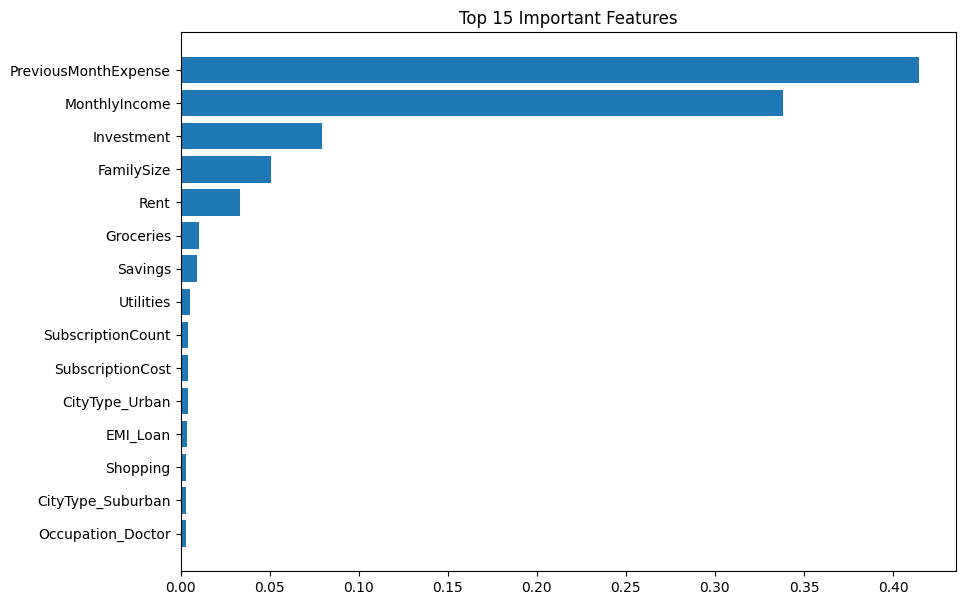

In [ ]:
plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [ ]:
joblib.dump(
    best_model,
    "expense_prediction_model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "feature_names.pkl"
)

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Everything Saved Successfully")

Everything Saved Successfully


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [ ]:
params = {

    "n_estimators": [200, 300, 500, 700],

    "max_depth": [3, 4, 5, 6, 8, 10],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5, 7],

    "gamma": [0, 0.1, 0.2, 0.3],

    "reg_alpha": [0, 0.1, 1],

    "reg_lambda": [1, 2, 5]

}

In [ ]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=params,

    n_iter=30,

    scoring="r2",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [ ]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8, 10],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [200, 300, 500, 700],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 2, 5],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
print("Best Parameters")

print(random_search.best_params_)

Best Parameters
{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}


In [ ]:
print("Best CV R²")

print(random_search.best_score_)

Best CV R²
0.919283315829644


In [ ]:
best_model = random_search.best_estimator_

In [ ]:
predictions = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

mape = mean_absolute_percentage_error(
    y_test,
    predictions
)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² :", round(r2,4))

print("MAPE :", round(mape*100,2),"%")

MAE : 20589.16
RMSE : 27736.42
R² : 0.923
MAPE : 8.91 %


In [ ]:
import joblib

joblib.dump(
    best_model,
    "expense_prediction_model_final.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "feature_names_final.pkl"
)

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                 Feature  Importance
18  PreviousMonthExpense    0.351747
4          MonthlyIncome    0.347543
5                   Rent    0.125855
16            Investment    0.076115
3             FamilySize    0.038689
6              Groceries    0.013592
17               Savings    0.005059
8              Utilities    0.004273
0                   Year    0.003622
13     SubscriptionCount    0.003400
14      SubscriptionCost    0.002608
19         FestivalMonth    0.002311
1                  Month    0.002190
11         Entertainment    0.002079
7         Transportation    0.002023
2                    Age    0.001952
10             Education    0.001934
28        CityType_Urban    0.001907
9             Healthcare    0.001882
12              Shopping    0.001835


In [ ]:
results = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Gradient Boosting",
        "XGBoost (Default)",
        "XGBoost (Tuned)"
    ],

    "MAE":[
        21085.81,
        21048.45,
        20660.09,
        20589.16
    ],

    "RMSE":[
        28520.71,
        28246.52,
        28009.45,
        27736.42
    ],

    "R2":[
        0.9186,
        0.9201,
        0.9215,
        0.9230
    ],

    "MAPE":[
        9.17,
        9.19,
        8.93,
        8.91
    ]

})

results

,Model,MAE,RMSE,R2,MAPE
0,Random Forest,21085.81,28520.71,0.9186,9.17
1,Gradient Boosting,21048.45,28246.52,0.9201,9.19
2,XGBoost (Default),20660.09,28009.45,0.9215,8.93
3,XGBoost (Tuned),20589.16,27736.42,0.9230,8.91


In [ ]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.to_csv(
    "feature_importance_finall.csv",
    index=False
)

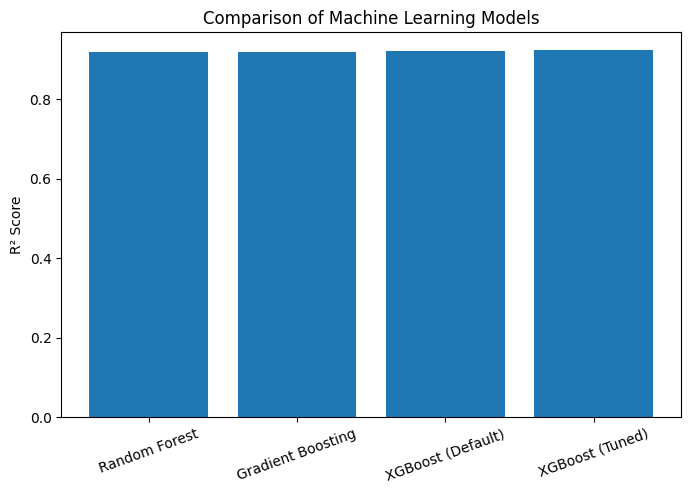

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.ylabel("R² Score")

plt.title("Comparison of Machine Learning Models")

plt.xticks(rotation=20)

plt.show()